## Linear regression workbook

This workbook will walk you through a linear regression example. It will provide familiarity with Jupyter Notebook and Python.  Please print (to pdf) a completed version of this workbook for submission with HW #1.

ECE C147/C247, Fall Quarter 2026

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

#allows matlab plots to be generated in line
%matplotlib inline 

### Data generation

For any example, we first have to generate some appropriate data to use. The following cell generates data according to the model: $y = x + 2x^2 -3x^3 + \epsilon$

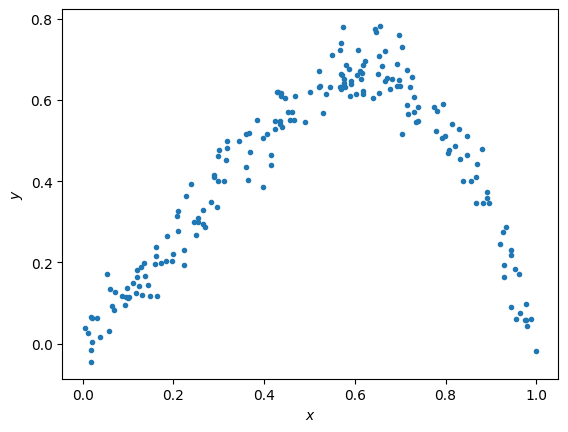

In [2]:
np.random.seed(0)  # Sets the random seed.
num_train = 200  # Number of training data points

# Generate the training data
x = np.random.uniform(low=0, high=1, size=(num_train,))
y = x + 2 * x**2 - 3 * x**3 + np.random.normal(loc=0, scale=0.05, size=(num_train,))
f = plt.figure()
ax = f.gca()
ax.plot(x, y, ".")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
plt.show()

### QUESTIONS:

Write your answers in the markdown cell below this one:

(1) What is the generating distribution of $x$?

(2) What is the distribution of the additive noise $\epsilon$?

### ANSWERS:

(1) The generating distribution of x is a uniform distribution bounded between 0 and 1 inclusive.

(2) The distribution of the additive noise epsilon is a normal distribution with mean 0 and standard deviation 0.05.

### Fitting data to the model (5 points)

Here, we'll do linear regression to fit the parameters of a model $y = ax + b$.

In [3]:
# xhat = (x, 1)
xhat = np.vstack((x, np.ones_like(x)))

# ==================== #
# START YOUR CODE HERE #
# ==================== #
# GOAL: create a variable theta; theta is a numpy array whose elements are [a, b]

theta = np.linalg.lstsq(xhat.T, y)[0] # using least-squares linear regression

# ================== #
# END YOUR CODE HERE #
# ================== #

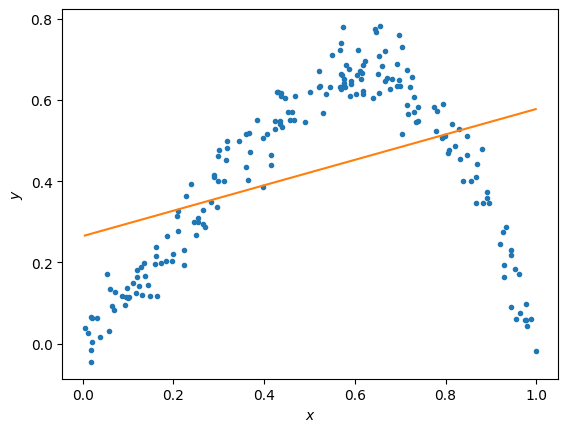

In [4]:
# Plot the data and your model fit.
f = plt.figure()
ax = f.gca()
ax.plot(x, y, ".")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

# Plot the regression line
xs = np.linspace(min(x), max(x), 50)
xs = np.vstack((xs, np.ones_like(xs)))
plt.plot(xs[0, :], theta.dot(xs))
plt.show()

### QUESTIONS

(1) Does the linear model under- or overfit the data?

(2) How to change the model to improve the fitting?

### ANSWERS

(1) Underfit; the model does not follow the shape of the data.

(2) Increasing to a second-degree polynomial (i.e. using a quadratic rather than a linear model) will improve the fitting.

### Fitting data to the model (5 points)

Here, we'll now do regression to polynomial models of orders 1 to 5.  Note, the order 1 model is the linear model you prior fit.

In [8]:
xhats = []
thetas = []

# ==================== #
# START YOUR CODE HERE #
# ==================== #

# GOAL: create a variable thetas.
# thetas is a list, where theta[i] are the model parameters for the polynomial fit of order i+1.
#   i.e., thetas[0] is equivalent to theta above.
#   i.e., thetas[1] should be a length 3 np.array with the coefficients of the x^2, x, and 1 respectively.
#   ... etc.

for degree in range(1, 6):
    xhat = np.vstack([x ** power for power in range(degree, -1, -1)]) # generate the polynomial terms
    xhats.append(xhat)
    thetas.append(np.linalg.lstsq(xhat.T, y)[0]) # scalable for any degree because this stays the same

# ================== #
# END YOUR CODE HERE #
# ================== #

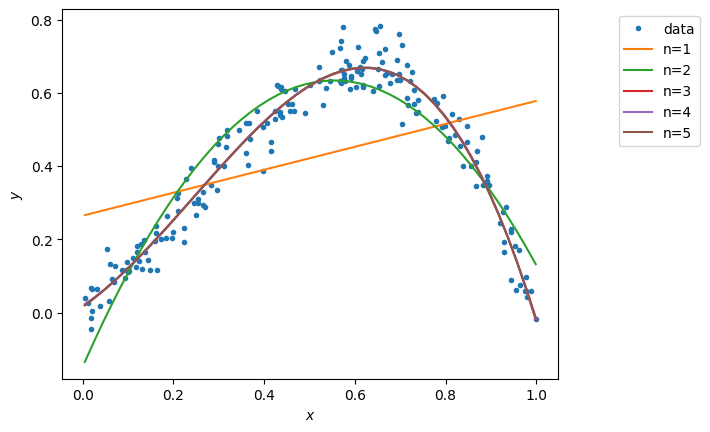

In [9]:
# Plot the data
f = plt.figure()
ax = f.gca()
ax.plot(x, y, ".")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

# Plot the regression lines
plot_xs = []
for i in np.arange(N):
    if i == 0:
        plot_x = np.vstack((np.linspace(min(x), max(x), 50), np.ones(50)))
    else:
        plot_x = np.vstack((plot_x[-2] ** (i + 1), plot_x))
    plot_xs.append(plot_x)

for i in np.arange(N):
    ax.plot(plot_xs[i][-2, :], thetas[i].dot(plot_xs[i]))

labels = ["data"]
[labels.append("n={}".format(i + 1)) for i in np.arange(N)]
bbox_to_anchor = (1.3, 1)
lgd = ax.legend(labels, bbox_to_anchor=bbox_to_anchor)
plt.show()

### Calculating the training error (5 points)

Here, we'll now calculate the training error of polynomial models of orders 1 to 5.

In [21]:
training_errors = []

# ==================== #
# START YOUR CODE HERE #
# ==================== #

# GOAL: create a variable training_errors, a list of 5 elements,
# where training_errors[i] are the training loss for the polynomial fit of order i+1.

for i in range(5):
    # using the mean-squared error formula, scales to larger theta dimensions
    total_error = np.mean((xhats[i].T.dot(thetas[i]) - y) ** 2)
    training_errors.append(round(float(total_error), 8))

# ================== #
# END YOUR CODE HERE #
# ================== #

print("Training errors are: \n", training_errors)

Training errors are: 
 [0.04189915, 0.00586028, 0.00226933, 0.00226815, 0.00226708]


### QUESTIONS

(1) What polynomial has the best training error?

(2) Why is this expected?

### ANSWERS

(1) The 5th degree polynomial has the best (lowest) training error.

(2) This is expected because the 5th degree polynomial has the most "model space" to explore, and this "model space" is a superset of the "model spaces" of the 4th-degree and below polynomials. Therefore, the highest-degree polynomial will have a training error that is either equal to or better (lower) than any polynomial with a lower degree.

### Generating new samples and testing error (5 points)

Here, we'll now generate new samples and calculate testing error of polynomial models of orders 1 to 5.

Text(0, 0.5, '$y$')

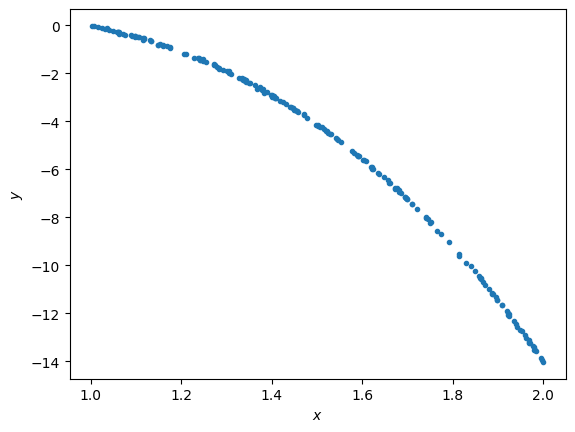

In [22]:
x = np.random.uniform(low=1, high=2, size=(num_train,))
y = x + 2 * x**2 - 3 * x**3 + np.random.normal(loc=0, scale=0.03, size=(num_train,))
f = plt.figure()
ax = f.gca()
ax.plot(x, y, ".")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

In [23]:
xhats = []
for i in np.arange(N):
    if i == 0:
        xhat = np.vstack((x, np.ones_like(x)))
        plot_x = np.vstack((np.linspace(min(x), max(x), 50), np.ones(50)))
    else:
        xhat = np.vstack((x ** (i + 1), xhat))
        plot_x = np.vstack((plot_x[-2] ** (i + 1), plot_x))

    xhats.append(xhat)

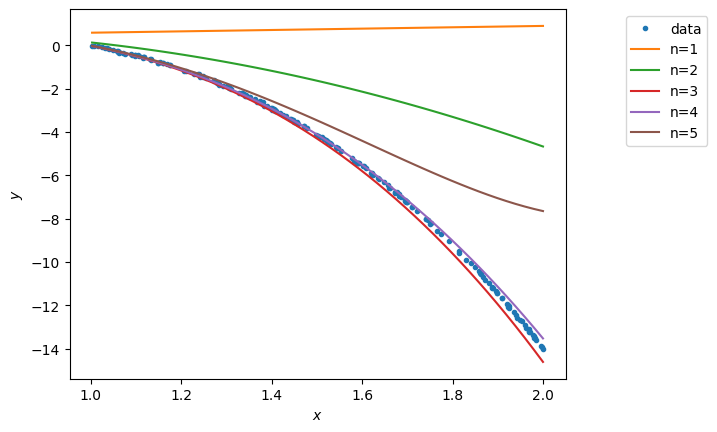

In [24]:
# Plot the data
f = plt.figure()
ax = f.gca()
ax.plot(x, y, ".")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

# Plot the regression lines
plot_xs = []
for i in np.arange(N):
    if i == 0:
        plot_x = np.vstack((np.linspace(min(x), max(x), 50), np.ones(50)))
    else:
        plot_x = np.vstack((plot_x[-2] ** (i + 1), plot_x))
    plot_xs.append(plot_x)

for i in np.arange(N):
    ax.plot(plot_xs[i][-2, :], thetas[i].dot(plot_xs[i]))

labels = ["data"]
[labels.append("n={}".format(i + 1)) for i in np.arange(N)]
bbox_to_anchor = (1.3, 1)
lgd = ax.legend(labels, bbox_to_anchor=bbox_to_anchor)
plt.show()

In [27]:
testing_errors = []

# ==================== #
# START YOUR CODE HERE #
# ==================== #

# GOAL: create a variable testing_errors, a list of 5 elements,
# where testing_errors[i] are the testing loss for the polynomial fit of order i+1.

for i in range(5):
    error = np.mean((xhats[i].T.dot(thetas[i]) - y) ** 2)
    testing_errors.append(round(float(error), 8))

# ================== #
# END YOUR CODE HERE #
# ================== #

print("Testing errors are: \n", testing_errors)

Testing errors are: 
 [54.24631772, 18.91115922, 0.08693863, 0.03042967, 5.95435634]


### QUESTIONS

(1) What polynomial has the best testing error?

(2) Why polynomial models of orders 5 does not generalize well?

### ANSWERS

(1) The fourth-degree polynomial has the best testing error.

(2) The first-degree, second-degree, and fifth-degree polynomial models do not generalize well.